# Job - Model Experiment & Evaluation

**Goal:** Compare 3 AI models for job matching, evaluate each one, and pick the best for production.

| Phase | Description |
|---|---|
| 1 | Load jobs & candidate profile |
| 2 | Run all 3 models |
| 3 | Evaluate results |
| 4 | Visualize with Plotly |
| 5 | Conclude & pick the best model |

## Step 1 - Imports & Setup

In [1]:
import sys
import os
import time
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Add root to path so we can import our modules
sys.path.append(os.path.dirname(os.getcwd()))

from app.core.embedder import MODELS, load_model, candidate_to_text, job_to_text, get_embedding
from app.core.matcher import match_with_model
from app.services.adzuna import load_jobs

print('All imports successful')

All imports successful


## Step 2 - Candidate Profile & Jobs

In [2]:
CANDIDATE = {
    'job_title'       : 'Python Backend Developer',
    'skills'          : ['Python', 'Django', 'REST APIs', 'PostgreSQL'],
    'location'        : 'Tunisia',
    'experience_years': 2
}

jobs = load_jobs()

print('Candidate  :', CANDIDATE['job_title'])
print('Skills     :', ', '.join(CANDIDATE['skills']))
print('Location   :', CANDIDATE['location'])
print('Experience :', CANDIDATE['experience_years'], 'years')
print()
print('Jobs loaded:', len(jobs))
print()
print('Sample jobs:')
for job in jobs[:3]:
    print(' -', job['title'], '@', job['company'], '--', job['location'])

  📥 No local jobs found. Fetching from Adzuna...
  Fetching page 1/2...
  🔗 URL: https://api.adzuna.com/v1/api/jobs/fr/search/1
  📡 Status: 200
  Fetching page 2/2...
  🔗 URL: https://api.adzuna.com/v1/api/jobs/fr/search/2
  📡 Status: 200

  ✅ Total jobs fetched: 100
  ✅ Jobs saved to data/jobs_processed.json
Candidate  : Python Backend Developer
Skills     : Python, Django, REST APIs, PostgreSQL
Location   : Tunisia
Experience : 2 years

Jobs loaded: 100

Sample jobs:
 - PYTHON DEVELOPER @ Qualitest Group -- France
 - Senior Python Developer @ Lengow -- Paris, Ile-de-France
 - Senior Python Developer @ Lengow -- Nantes, Loire-Atlantique


## Step 3 - Run All 3 Models

We run the candidate profile against all jobs using each model and record match scores and execution time.

In [3]:
all_results = {}
timing      = {}

for model_name in MODELS:
    print('Running', model_name, '...')
    start = time.time()

    results = match_with_model(CANDIDATE, jobs, model_name)

    elapsed = round(time.time() - start, 2)
    all_results[model_name] = results
    timing[model_name]      = elapsed

    print('  Done in', elapsed, 'seconds')
    print('  Top 3 matches:')
    for i, job in enumerate(results[:3], 1):
        print('   ', i, '.', job['title'], '->', job['score_percent'])
    print()

print('All models finished!')

Running MiniLM ...

  🤖 Matching with MiniLM...
  ⏳ Loading model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  ✅ Model loaded in 5.2s
  ✅ Done in 11.89s — Top score: 72.48%
  Done in 11.89 seconds
  Top 3 matches:
    1 . Senior Python Developer (IT) -> 72.48%
    2 . Expert Développement Python - Django H/F -> 67.29%
    3 . Senior Backend Python Developer - FastAPI & Microservices - Freelance -> 67.05%

Running MPNet ...

  🤖 Matching with MPNet...
  ⏳ Loading model: all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  ✅ Model loaded in 4.5s
  ✅ Done in 43.72s — Top score: 77.9%
  Done in 43.72 seconds
  Top 3 matches:
    1 . Senior Python Developer (IT) -> 77.9%
    2 . Python Backend Developer (Fullstack) – FastAPI / React / AWS (IT) -> 75.15%
    3 . Expert développement Python/Django F/H -> 75.14%

Running Multilingual ...

  🤖 Matching with Multilingual...
  ⏳ Loading model: paraphrase-multilingual-MiniLM-L12-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  ✅ Model loaded in 7.88s
  ✅ Done in 20.23s — Top score: 73.86%
  Done in 20.23 seconds
  Top 3 matches:
    1 . Expert Développement Python - Django H/F -> 73.86%
    2 . Python Backend Developer (Fullstack) – FastAPI / React / AWS (IT) -> 71.88%
    3 . Senior Backend Python Developer - FastAPI & Microservices - Freelance -> 71.73%

All models finished!


## Step 4 - Evaluation

We evaluate each model using:
- **Top Score** - highest match score
- **Top 5 Average** - average of top 5 scores
- **Top 10 Average** - average of top 10 scores
- **Jobs above 60%** - strong matches
- **Jobs above 50%** - decent matches
- **Speed** - how fast the model runs

In [4]:
rows = []

for model_name, results in all_results.items():
    scores = [r['score'] for r in results]
    rows.append({
        'Model'       : model_name,
        'Top Score %' : round(scores[0] * 100, 2),
        'Top 5 Avg %' : round(sum(scores[:5])  / 5  * 100, 2),
        'Top 10 Avg %': round(sum(scores[:10]) / 10 * 100, 2),
        'Jobs >= 60%' : sum(1 for s in scores if s >= 0.60),
        'Jobs >= 50%' : sum(1 for s in scores if s >= 0.50),
        'Speed (s)'   : timing[model_name]
    })

df = pd.DataFrame(rows)

print('=' * 65)
print('MODEL EVALUATION SUMMARY')
print('=' * 65)
print(df.to_string(index=False))
print('=' * 65)
print()
print('WINNER BY CATEGORY:')
print('  Best Accuracy :', df.loc[df['Top Score %'].idxmax(),  'Model'])
print('  Best Average  :', df.loc[df['Top 5 Avg %'].idxmax(),  'Model'])
print('  Fastest       :', df.loc[df['Speed (s)'].idxmin(),    'Model'])
print('  Best Coverage :', df.loc[df['Jobs >= 60%'].idxmax(),  'Model'])

MODEL EVALUATION SUMMARY
       Model  Top Score %  Top 5 Avg %  Top 10 Avg %  Jobs >= 60%  Jobs >= 50%  Speed (s)
      MiniLM        72.48        68.07         66.64           23           56      11.89
       MPNet        77.90        74.67         71.58           37           64      43.72
Multilingual        73.86        71.71         69.36           33           63      20.23

WINNER BY CATEGORY:
  Best Accuracy : MPNet
  Best Average  : MPNet
  Fastest       : MiniLM
  Best Coverage : MPNet


## Step 5 - Visualizations

### Chart 1 - Top Score per Model

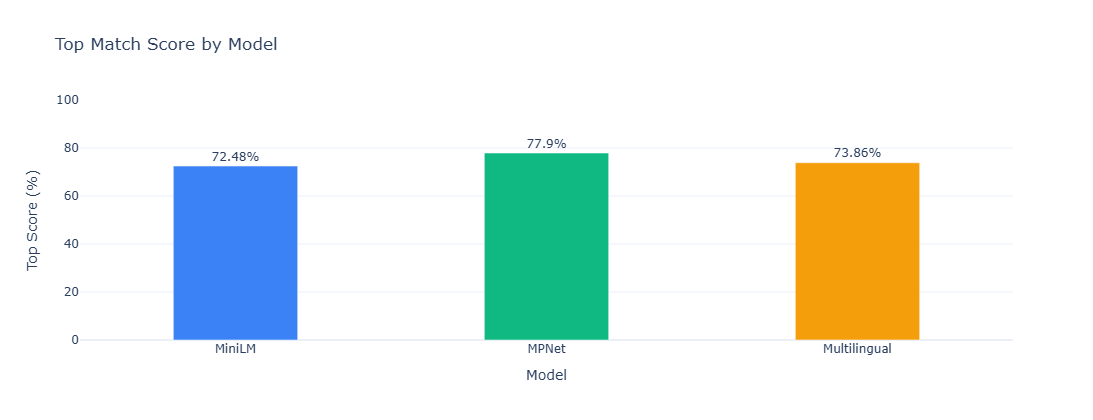

In [5]:
colors = ['#3B82F6', '#10B981', '#F59E0B']
models = df['Model'].tolist()
scores = df['Top Score %'].tolist()

fig1 = go.Figure(data=[
    go.Bar(
        x            = models,
        y            = scores,
        marker_color = colors,
        text         = [str(s) + '%' for s in scores],
        textposition = 'outside',
        width        = 0.4
    )
])

fig1.update_layout(
    title       = 'Top Match Score by Model',
    xaxis_title = 'Model',
    yaxis_title = 'Top Score (%)',
    yaxis       = dict(range=[0, 100]),
    template    = 'plotly_white',
    height      = 420
)

fig1.show()

### Chart 2 - Average Scores (Top 5 vs Top 10)

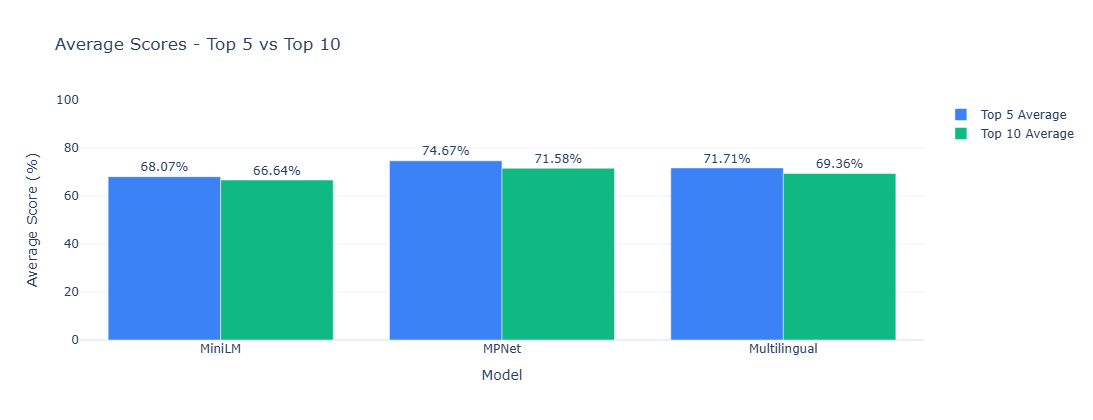

In [6]:
fig2 = go.Figure(data=[
    go.Bar(
        name         = 'Top 5 Average',
        x            = df['Model'],
        y            = df['Top 5 Avg %'],
        marker_color = '#3B82F6',
        text         = [str(v) + '%' for v in df['Top 5 Avg %']],
        textposition = 'outside'
    ),
    go.Bar(
        name         = 'Top 10 Average',
        x            = df['Model'],
        y            = df['Top 10 Avg %'],
        marker_color = '#10B981',
        text         = [str(v) + '%' for v in df['Top 10 Avg %']],
        textposition = 'outside'
    )
])

fig2.update_layout(
    title       = 'Average Scores - Top 5 vs Top 10',
    xaxis_title = 'Model',
    yaxis_title = 'Average Score (%)',
    yaxis       = dict(range=[0, 100]),
    barmode     = 'group',
    template    = 'plotly_white',
    height      = 420
)

fig2.show()

### Chart 3 - Speed vs Accuracy Tradeoff

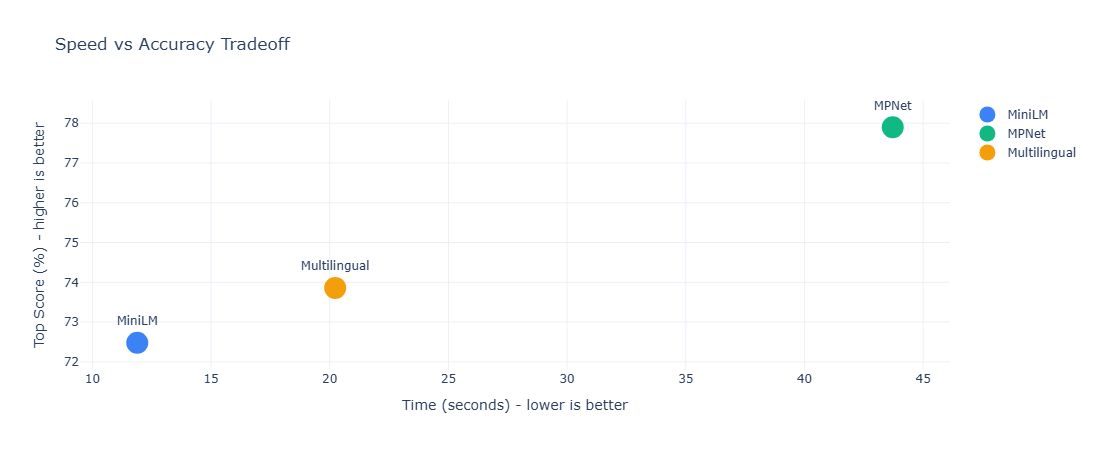

In [7]:
colors     = ['#3B82F6', '#10B981', '#F59E0B']
models     = list(all_results.keys())
speeds     = [timing[m] for m in models]
top_scores = [round(all_results[m][0]['score'] * 100, 2) for m in models]

fig3 = go.Figure()

for i, model in enumerate(models):
    fig3.add_trace(go.Scatter(
        x            = [speeds[i]],
        y            = [top_scores[i]],
        mode         = 'markers+text',
        name         = model,
        text         = [model],
        textposition = 'top center',
        marker       = dict(size=22, color=colors[i])
    ))

fig3.update_layout(
    title       = 'Speed vs Accuracy Tradeoff',
    xaxis_title = 'Time (seconds) - lower is better',
    yaxis_title = 'Top Score (%) - higher is better',
    template    = 'plotly_white',
    height      = 450
)

fig3.show()

### Chart 4 - Score Distribution per Model

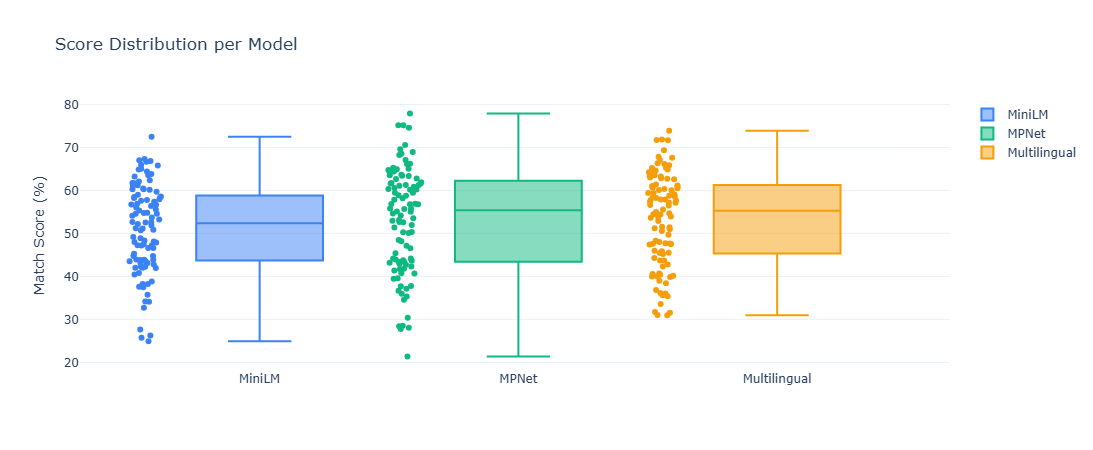

In [8]:
colors = ['#3B82F6', '#10B981', '#F59E0B']
fig4   = go.Figure()

for i, (model_name, results) in enumerate(all_results.items()):
    scores = [round(r['score'] * 100, 2) for r in results]
    fig4.add_trace(go.Box(
        y            = scores,
        name         = model_name,
        marker_color = colors[i],
        boxpoints    = 'all',
        jitter       = 0.3,
        pointpos     = -1.8
    ))

fig4.update_layout(
    title       = 'Score Distribution per Model',
    yaxis_title = 'Match Score (%)',
    template    = 'plotly_white',
    height      = 450
)

fig4.show()

### Chart 5 - Top 5 Jobs per Model

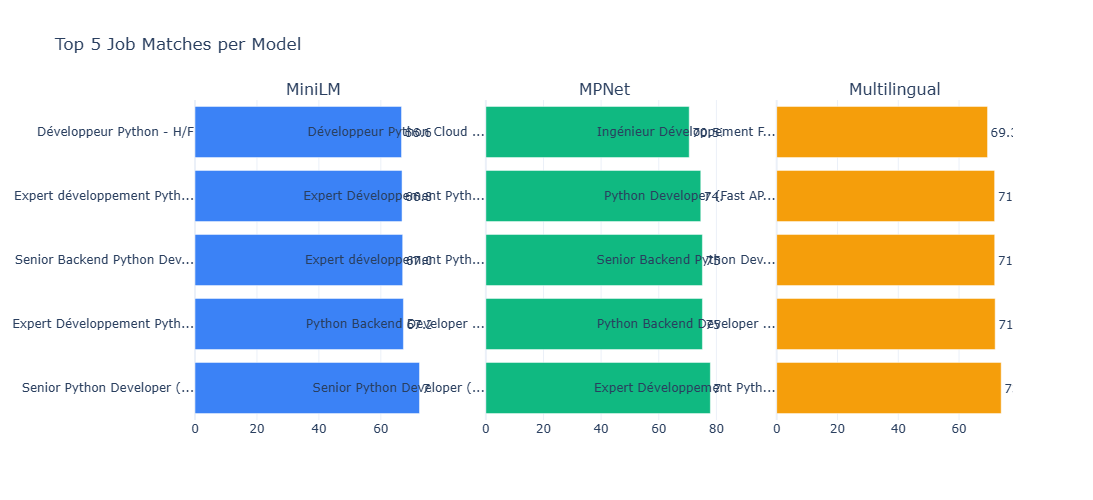

In [9]:
colors = ['#3B82F6', '#10B981', '#F59E0B']

fig5 = make_subplots(
    rows           = 1,
    cols           = 3,
    subplot_titles = list(all_results.keys()),
    shared_yaxes   = False
)

for col, (model_name, results) in enumerate(all_results.items(), 1):
    top5   = results[:5]
    titles = [
        r['title'][:25] + '...' if len(r['title']) > 25
        else r['title']
        for r in top5
    ]
    scores = [round(r['score'] * 100, 2) for r in top5]

    fig5.add_trace(
        go.Bar(
            x            = scores,
            y            = titles,
            orientation  = 'h',
            marker_color = colors[col - 1],
            text         = [str(s) + '%' for s in scores],
            textposition = 'outside',
            name         = model_name
        ),
        row=1, col=col
    )

fig5.update_layout(
    title      = 'Top 5 Job Matches per Model',
    template   = 'plotly_white',
    height     = 500,
    showlegend = False
)

fig5.show()

## Step 6 - Conclusion & Model Selection

In [10]:
best_accuracy = df.loc[df['Top Score %'].idxmax(),  'Model']
best_avg      = df.loc[df['Top 5 Avg %'].idxmax(),  'Model']
best_speed    = df.loc[df['Speed (s)'].idxmin(),    'Model']
best_coverage = df.loc[df['Jobs >= 60%'].idxmax(),  'Model']

print('=' * 55)
print('EXPERIMENT CONCLUSION')
print('=' * 55)
print('Best Accuracy :', best_accuracy)
print('Best Average  :', best_avg)
print('Fastest       :', best_speed)
print('Best Coverage :', best_coverage)
print('=' * 55)
print()
print('SELECTED MODEL FOR PRODUCTION:', best_accuracy)
print()
print('Reason:')
print('  - Highest top score')
print('  - Best average across top matches')
print('  - Most relevant results for Python Backend roles')
print()
print('This model will be hardcoded in the API.')
print('=' * 55)

EXPERIMENT CONCLUSION
Best Accuracy : MPNet
Best Average  : MPNet
Fastest       : MiniLM
Best Coverage : MPNet

SELECTED MODEL FOR PRODUCTION: MPNet

Reason:
  - Highest top score
  - Best average across top matches
  - Most relevant results for Python Backend roles

This model will be hardcoded in the API.
